**Courtesy:**
https://pypi.org/project/gpax/#:~:text=GPax%20is%20a%20small%20Python,data%20reconstruction%20and%20active%20learning.

Installing and importing useful packages like 'numpyro', 'gpax', 'arviz' etc.

**Numpyro:** NumPyro is a probabilistic programming library for Python that is built on top of NumPy and PyTorch. Probabilistic programming allows us to express probabilistic models using a high-level syntax and then perform inference to learn about the hidden structure in the data.
**Gpax:** GPax is a small Python package for physics-based Gaussian processes (GPs) built on top of NumPyro and JAX. Its purpose is to take advantage of prior physical knowledge and different data modalities when using GPs for data reconstruction and active learning. (Courtesy:[gpax 0.1.1](https://pypi.org/project/gpax/#:~:text=GPax%20is%20a%20small%20Python,data%20reconstruction%20and%20active%20learning.) by Author: [ Maxim Ziatdinov](maxim.ziatdinov@ai4microcopy.com))           
**Arviz:** ArviZ is a Python library for exploratory analysis of Bayesian models. It is designed to work with probabilistic programming libraries such as PyMC3, PyStan, and others. ArviZ provides a set of tools for analyzing and visualizing the output of Bayesian models to help users better understand the results of their probabilistic models.




In [ ]:
!pip install numpyro==0.10.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.7/291.7 kB 9.2 MB/s eta 0:00:00


In [ ]:
!pip install -U gpax  # Update gpax to the latest version

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.0/78.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.3/374.3 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.4/172.4 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 384.1/384.1 kB 24.8 MB/s eta 0:00:00
  Attempting uninstall: numpyro
    Found existing installation: numpyro 0.10.0
    Uninstalling numpyro-0.10.0:
      Successfully uninstalled numpyro-0.10.0


In [ ]:
import gpax
import numpy as np
import matplotlib.pyplot as plt
import numpyro
import arviz as az
gpax.utils.enable_x64()
import scipy
from scipy.interpolate import interp1d
from scipy.spatial.distance import cdist
from scipy.special import kv, gamma

## **FORWARD MODELLING**
Generation of synthetic model of constant density contrast and synthetic gravity anomaly

In [ ]:
#Definng a new function g_anomaly to calculate gravity anomaly for a single prism
import numpy as np
def g_anomaly(x,A,m,D,d,rho):
    G=6.67*(10**-6)
    r1=(((x-A)+(0.5*m))**2)+((d)**2)
    r2=(((x-A)+(0.5*m))**2)+((D*1000)**2)
    r3=(((x-A)-(0.5*m))**2)+((d)**2)
    r4=(((x-A)-(0.5*m))**2)+((D*1000)**2)
    f1=np.arctan((x-A+(0.5*m))/(D*1000))-np.arctan((x-A-(0.5*m))/(D*1000))
    f2=np.arctan((x-A+(0.5*m))/d)-np.arctan((x-A-(0.5*m))/d)
    f3=0.5*(x-A)*(np.log10((r2*r3)/(r1*r4)))
    f4=0.25*m*(np.log10((r2*r4)/(r1*r3)))
    f=((D*1000)*f1)-(d*f2)+f3+f4
    g=2*G*rho*1000*f
    return g

In [ ]:
G = 6.67*(10**-6) #Gravitational constant in SI

D1= 0.3 #Lower end depth of the 1st prism in km
d1=0.001 #Upper end depth of the 1st prism in meter
m1=30.1 #width of the 1st prism in meter
rho1=2.7 #density of the 1st prism in gm/cc
A1= -50.1 #Co-ordinate of 1st prism in horizontal(X) direction

D2= 0.5 #Lower end depth of the 2nd prism in km
d2=0.001 #Upper end depth of the 2nd prism in meter
m2=30.1 #width of the 2nd prism in meter
rho2=2.2 #density of the 2nd prism in gm/cc
A2= 50.1 #Co-ordinate of 2nd prism in horizontal(X) direction

In [ ]:
#Defining "measure_func" function to calculate gravity anomaly in miligal with user defined station coordinates and above defined model parameters with some added random noise
def measure_func(x):
    return g_anomaly(x,A1,m1,D1,d1,rho1)+g_anomaly(x,A2,m2,D2,d2,rho2)

In [ ]:
NUM_INIT_POINTS = 50 # number of observation points

X = np.linspace(-75,75, NUM_INIT_POINTS) #Measurement points along the profile -75 meter to 75 meter
X_test = np.linspace(-75,75, 200) #points taken for testing at finer intervals
ground_truth=measure_func(X_test) #Gravity anomaly in miligal at finer intervals with no addedcnoise

In [ ]:
import numpy as np
import tensorflow as tf
# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
# For PyTorch: torch.manual_seed(SEED)
#Generate Gaussian Noise
gaussian_noise = np.random.normal(0, 0.02, size=X.shape)
# Generate Random Walk Noise
# Step size is drawn from a normal distribution
random_steps = np.random.normal(0, 0.02, size=X.shape)
random_walk_noise = np.cumsum(random_steps)  # Cumulative sum to simulate random walk
#Salt & Pepper noise
salt_prob=0.05 #probability of salt(white) noise
pepper_prob=0.05 #probability of pepper(black) noise
noise_level=0.02 # 2% Salt & Pepper noise
salt_and_pepper_noise = (np.random.choice([0,1,-1],size=X.shape,p=[1 - (salt_prob + pepper_prob),salt_prob,pepper_prob]))*noise_level
#Systematic Noise (Assuming polynomial pattern of systematic noise with distance(x))
a,b,c=0.001,0.0001,0.001 #Co-efficients of Quadratic & Cubic terms
systematic_noise_level=0.01 # 1% Systematic noise
systematic_noise = systematic_noise_level*((a*((X*0.1)**2))+(b*((X*0.1)**3))+c)

#Adding noise to the gravity anomaly data

y = measure_func(X) + random_walk_noise+ gaussian_noise+salt_and_pepper_noise+systematic_noise #Gravity anomaly in miligal at station points with added noise (OBSERVED ANOMALY)
y_f=interp1d(X,y,'linear')
y_true=y_f(X_test)#interpolating between noisy observations at finer fintervals

*Plotting the synthetic model along with observed gravity anomaly*

[None, None, None, None, None, None]

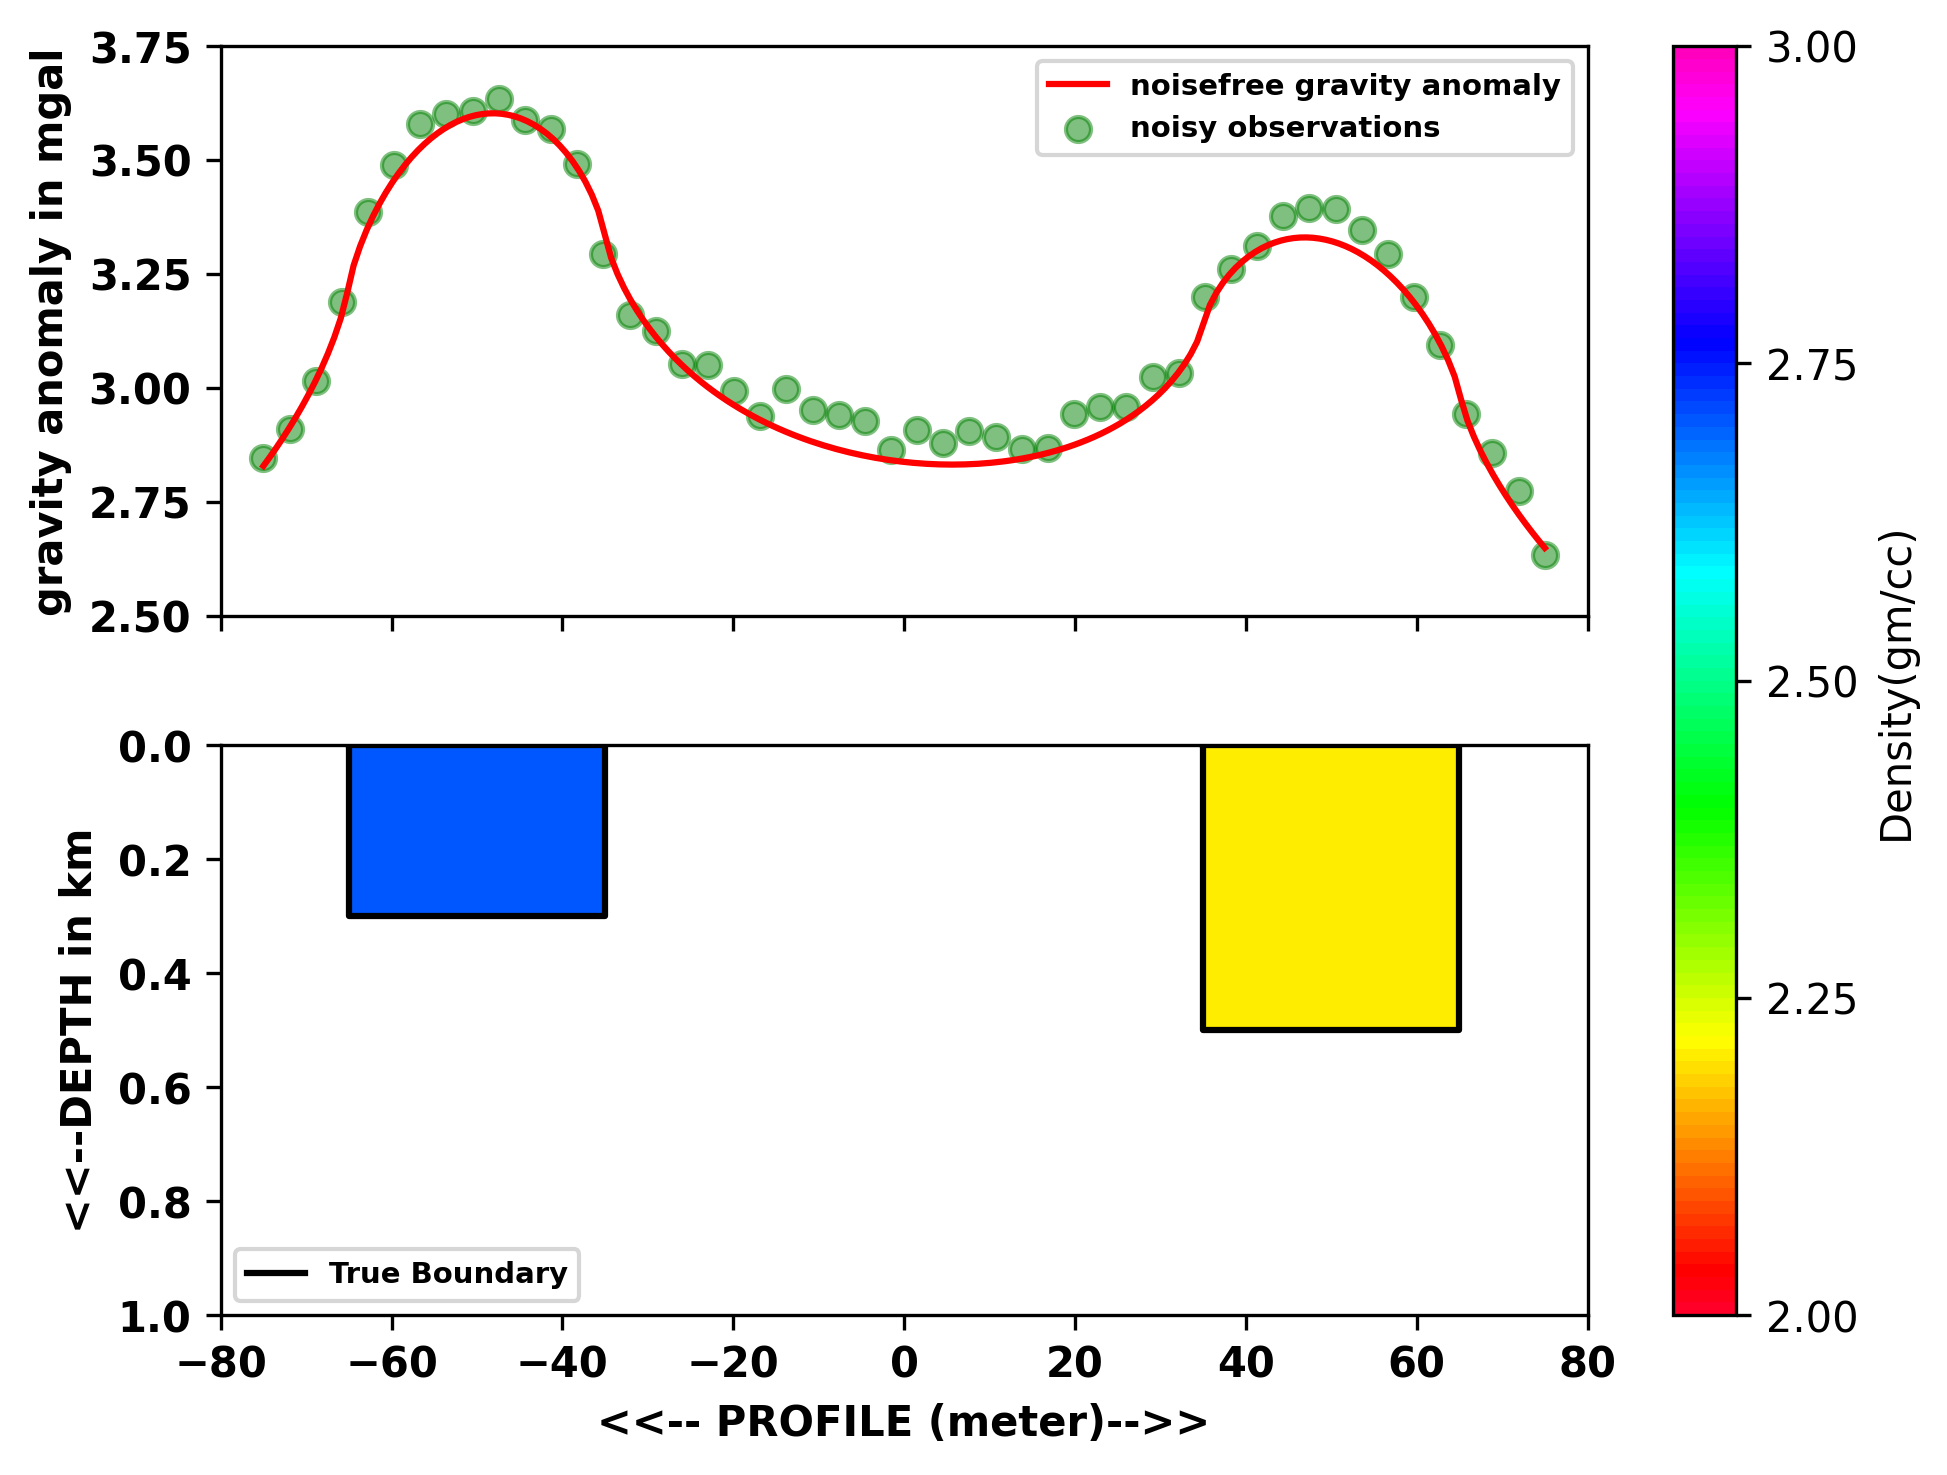

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

#import matplotlib.pyplot as plt
fig, axs = plt.subplots(2)
fig.tight_layout(pad=1)
fig.dpi=300
cmap_V= plt.get_cmap('gist_rainbow',100)
maximum_V=3 #maximum density value in color scale in gm/cc
minimum_V=2 #minimum density value in color scale in gm/cc
diff_V=(maximum_V - minimum_V)
color_index_V = np.linspace(minimum_V,maximum_V,10)#creating colorscale within the min to max range
#choosing the color depending upon the density value of 1st prism
index_value_V1 = (rho1-minimum_V)/diff_V
color_V1 = cmap_V(index_value_V1)
#choosing the color depending upon the density value of 2nd prism
index_value_V2 = (rho2-minimum_V)/diff_V
color_V2 = cmap_V(index_value_V2)
norm = mpl.colors.Normalize(vmin=minimum_V, vmax=maximum_V)
# creating ScalarMappable
sm = plt.cm.ScalarMappable(cmap=cmap_V, norm=norm)
sm.set_array([])
#plotting color scale
plt.colorbar(sm, ticks=np.linspace(minimum_V,maximum_V,5),ax=axs.ravel().tolist(),label='Density(gm/cc)')

for i in range(1):
    #creating a prism using 4 corner co-ordinates
    coord1 = [[-65,0], [-35,0], [-35,0.3], [-65,0.3]]
    coord2 = [[35,0], [65,0], [65,0.5], [35,0.5]]
    coord1.append(coord1[0]) #repeat the first point to create a 'closed loop'
    coord2.append(coord2[0]) #repeat the first point to create a 'closed loop'
    xs1, ys1 = zip(*coord1) #create lists of x and y values
    xs2, ys2 = zip(*coord2) #create lists of x and y values

    axs[1].plot(xs1,ys1,'k')#plotting prism1
    axs[1].fill(xs1, ys1, facecolor=color_V1)#color filling the prism1 acc to its density value
    axs[1].plot(xs2,ys2,'k')#plotting prism2
    axs[1].fill(xs2, ys2, facecolor=color_V2)#color filling the prism2 acc to its density value

    axs[1].set_xlim(-80,80)
    axs[1].set_ylim(1,0)
    legend_properties = {'weight':'bold','size':'7'}
    axs[1].legend(['True Boundary'],prop=legend_properties)
    axs[1].set_xlabel('<<-- PROFILE (meter)-->>',fontsize=10,weight='bold')
    axs[1].set_ylabel("<<--DEPTH in km",fontsize=10,weight='bold')
    plt.xticks(weight='bold')
    plt.yticks(weight='bold')


#Plotting gravity anomaly
axs[0].plot(X_test, ground_truth, c='red') #noisefree anomaly
axs[0].scatter(X, y, alpha=0.5, c='g', marker='o') #observed data
axs[0].legend(['noisefree gravity anomaly','noisy observations'],prop=legend_properties)
axs[0].set_ylabel("gravity anomaly in mgal",fontsize=10,weight='bold')
axs[0].set_xlim(-80,80)
axs[0].set_ylim(2.5,3.75)
plt.setp(axs[0].get_xticklabels(), visible= False)
plt.setp(axs[0].get_yticklabels(), weight='bold')

## **INVERSE MODELLING**

# STANDARD VS STRUCTURAL GP              
**Standard Gaussian Process**:* It is a generalization of a multivariate Gaussian distribution to an infinite number of variables. A standard Gaussian process typically has a mean function that is zero everywhere. The defining characteristic of a Gaussian process is its covariance function, also known as a kernel function. The choice of kernel determines the properties of the GP. A common choice for the standard GP is the squared exponential (or radial basis function) kernel. The kernel encodes the assumptions about the smoothness and structure of the underlying function being modeled.
For this problem, we have used 'Matern Kernal'.
The Matérn kernel is defined by the following formula:
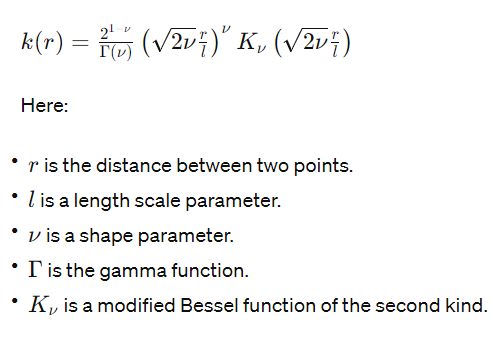               
**Structural Gaussian Process:** In this approach, we replace a constant Gaussian process (GP) prior mean function m with a structured probabilistic model representing the expected behaviour of the system. This probabilistic model incorporates our prior knowledge about the system, although it does not need to be exact.

Now, we will try GP augmented by a probabilistic models of expected system's behavior. We have used JAX's version of numpy for defining operations on arrays and NumPyro for placing priors over model parameters.

In [ ]:
from typing import Dict
import jax.numpy as jnp

**STRUCTURED GP**

Defining Model and priors over parameters of the model (to make it probabilistic)

In [ ]:
#First defining the function g_ano() replacing jnp in place of np in the g_anomaly() function.
from os import name
def g_ano(x,A,m,D,d,rho):
    G=6.67*(10**-6)
    r1=(((x-A)+(0.5*m))**2)+((d)**2)
    r2=(((x-A)+(0.5*m))**2)+((D*1000)**2)
    r3=(((x-A)-(0.5*m))**2)+((d)**2)
    r4=(((x-A)-(0.5*m))**2)+((D*1000)**2)
    f1=jnp.arctan((x-A+(0.5*m))/(D*1000))-jnp.arctan((x-A-(0.5*m))/(D*1000))
    f2=jnp.arctan((x-A+(0.5*m))/d)-jnp.arctan((x-A-(0.5*m))/d)
    f3=0.5*(x-A)*(jnp.log10((r2*r3)/(r1*r4)))
    f4=0.25*m*(jnp.log10((r2*r4)/(r1*r3)))
    f=((D*1000)*f1)-(d*f2)+f3+f4
    return 2*G*rho*1000*f

#Now defining a model Bayes_1_Inf() based on the prior knowledge of gravity anomaly generation for layers to use in the inversion.
def Bayes_1_Inf(x,params):
    G=6.67*(10**-6)
    B_D1 = params["B_D1"]
    density1 = params["density_1"]
    B_D2 = params["B_D2"]
    density2 = params["density_2"]
    v1=g_ano(x,A1,m1,B_D1,d1,density1)
    v2=g_ano(x,A2,m2,B_D2,d2,density2)
    u=v1+v2
    return u

In [ ]:
import numpy as np
import tensorflow as tf
# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
# For PyTorch: torch.manual_seed(SEED)
## CHANGE THE PARAMETERS AS PREVIOUS BY SEEING PREVIOUS NOTEPAD FILE ##
#PRIORS (Narrow range)
def Bayes_1_Inf_prior():
    return{
        "B_D1" : numpyro.sample("B_D1", numpyro.distributions.Uniform(0, 0.7)),
        "B_D2" : numpyro.sample("B_D2", numpyro.distributions.Uniform(0.2, 0.9)),
        "density_2" : numpyro.sample("density_2", numpyro.distributions.Uniform(2,3)),
        "density_1" : numpyro.sample("density_1", numpyro.distributions.Uniform(2,3))
    }

Running a 'structured' GP for the model. We have also keep in mind that, if we want to make our GP 'structured', we should pass the mean function (deterministic function) and mean function prior arguments to it at the initialization stage. If we define mean function as zero, we will revert to standard GP.

**CREATING CUSTOM KERNELS AND CUSTOM KERNEL PARAMETER FUNCTIONS FOR HYPER-PARAMETER TUNING**

In [ ]:
# CUSTOM MATERN KERNEL AND KERNEL PRIORS FOR v=3/2 & FOR v=5/2

import jax.numpy as jnp
from jax import vmap
import numpyro
import numpyro.distributions as dist
#from typing import Dict
from typing import Dict, Callable # Import Callable from typing
std_estimate=y.std()

# CUSTOM MATERN KERNEL FOR v=1/2
def custom_Matern_kernel_1(X1: jnp.ndarray, X2: jnp.ndarray, params: Dict[str, jnp.ndarray],noise: jnp.ndarray = 0, **kwargs) -> jnp.ndarray:
    """
    Matern 1/2 kernel with ARD support and numerical stability

    Args:
        X1: Input array of shape (n_samples, n_features)
        X2: Input array of shape (n_samples, n_features)
        params: Dictionary of kernel parameters
            - k_length: lengthscale (array-like for ARD)
            - k_scale: output scale (scalar)
        noise: Observation noise variance
        **jitter: Numerical stability term
    Returns:
        Covariance matrix of shape (n_samples, n_samples)
    """
    # Get parameters with safety checks
    lengthscale = params["k_length"]
    variance = params["k_scale"] ** 2  # Square to match standard convention
    jitter = kwargs.get("jitter", 1e-6)
    X1 = X1 / lengthscale
    X2 = X2 / lengthscale

    # ARD handling
    if lengthscale.ndim == 0 or lengthscale.shape[0] == 1:
        # Isotropic kernel
        X1_scaled = X1 / lengthscale
        X2_scaled = X2 / lengthscale
    else:
        # ARD kernel
        X1_scaled = X1 / jnp.sqrt(lengthscale)
        X2_scaled = X2 / jnp.sqrt(lengthscale)

    # Compute pairwise distances
    D = jnp.sum(X1**2, axis=1)[:, None] + \
        jnp.sum(X2**2, axis=1) - \
        2 * jnp.dot(X1, X2.T)
    D = jnp.sqrt(jnp.maximum(D, 1e-12))  # Ensure non-negative

    # Matern 5/2 formula
    sqrt1=jnp.sqrt(1)
    K=variance**jnp.exp(-sqrt1*D)
    # The following line is changed to add the jitter to the diagonal only when X1 and X2 are the same
    if X1.shape == X2.shape:
        K += (noise + jitter) * jnp.eye(X1.shape[0])
    return K


# CUSTOM MATERN KERNEL FOR v=3/2
def custom_Matern_kernel_2(X1: jnp.ndarray, X2: jnp.ndarray, params: Dict[str, jnp.ndarray],noise: jnp.ndarray = 0, **kwargs) -> jnp.ndarray:
    """
    Matern 3/2 kernel with ARD support and numerical stability

    Args:
        X1: Input array of shape (n_samples, n_features)
        X2: Input array of shape (n_samples, n_features)
        params: Dictionary of kernel parameters
            - k_length: lengthscale (array-like for ARD)
            - k_scale: output scale (scalar)
        noise: Observation noise variance
        **jitter: Numerical stability term
    Returns:
        Covariance matrix of shape (n_samples, n_samples)
    """
    # Get parameters with safety checks
    lengthscale = params["k_length"]
    variance = params["k_scale"] ** 2  # Square to match standard convention
    jitter = kwargs.get("jitter", 1e-6)
    X1 = X1 / lengthscale
    X2 = X2 / lengthscale

    # ARD handling
    if lengthscale.ndim == 0 or lengthscale.shape[0] == 1:
        # Isotropic kernel
        X1_scaled = X1 / lengthscale
        X2_scaled = X2 / lengthscale
    else:
        # ARD kernel
        X1_scaled = X1 / jnp.sqrt(lengthscale)
        X2_scaled = X2 / jnp.sqrt(lengthscale)

    # Compute pairwise distances
    D = jnp.sum(X1**2, axis=1)[:, None] + \
        jnp.sum(X2**2, axis=1) - \
        2 * jnp.dot(X1, X2.T)
    D = jnp.sqrt(jnp.maximum(D, 1e-12))  # Ensure non-negative

    # Matern 3/2 formula
    sqrt3 = jnp.sqrt(3.0)
    K = variance * (1 + sqrt3 * D) * jnp.exp(-sqrt3 * D)
    # The following line is changed to add the jitter to the diagonal only when X1 and X2 are the same
    if X1.shape == X2.shape:
        K += (noise + jitter) * jnp.eye(X1.shape[0])
    return K

# CUSTOM MATERN KERNEL FOR v=5/2

import jax.numpy as jnp
from jax import vmap
import numpyro
import numpyro.distributions as dist
#from typing import Dict
from typing import Dict, Callable # Import Callable from typing

def custom_Matern_kernel_3(X1: jnp.ndarray, X2: jnp.ndarray, params: Dict[str, jnp.ndarray],noise: jnp.ndarray = 0, **kwargs) -> jnp.ndarray:
    """
    Matern 5/2 kernel with ARD support and numerical stability

    Args:
        X1: Input array of shape (n_samples, n_features)
        X2: Input array of shape (n_samples, n_features)
        params: Dictionary of kernel parameters
            - k_length: lengthscale (array-like for ARD)
            - k_scale: output scale (scalar)
        noise: Observation noise variance
        **jitter: Numerical stability term
    Returns:
        Covariance matrix of shape (n_samples, n_samples)
    """
    # Get parameters with safety checks
    lengthscale = params["k_length"]
    variance = params["k_scale"] ** 2  # Square to match standard convention
    jitter = kwargs.get("jitter", 1e-6)
    X1 = X1 / lengthscale
    X2 = X2 / lengthscale

    # ARD handling
    if lengthscale.ndim == 0 or lengthscale.shape[0] == 1:
        # Isotropic kernel
        X1_scaled = X1 / lengthscale
        X2_scaled = X2 / lengthscale
    else:
        # ARD kernel
        X1_scaled = X1 / jnp.sqrt(lengthscale)
        X2_scaled = X2 / jnp.sqrt(lengthscale)

    # Compute pairwise distances
    D = jnp.sum(X1**2, axis=1)[:, None] + \
        jnp.sum(X2**2, axis=1) - \
        2 * jnp.dot(X1, X2.T)
    D = jnp.sqrt(jnp.maximum(D, 1e-12))  # Ensure non-negative

    # Matern 5/2 formula
    sqrt5=jnp.sqrt(5)
    K=variance*(1+sqrt5*D+(5/3)*D**2)*jnp.exp(-sqrt5*D)
    # The following line is changed to add the jitter to the diagonal only when X1 and X2 are the same
    if X1.shape == X2.shape:
        K += (noise + jitter) * jnp.eye(X1.shape[0])
    return K

def custom_RBF_kernel(X1: jnp.ndarray, X2: jnp.ndarray, params: Dict[str, jnp.ndarray],noise: jnp.ndarray = 0, **kwargs) -> jnp.ndarray:
    """
    Radial Basis Function (RBF) kernel (Gaussian kernel)

    Args:
        X1: Input array of shape (n_samples, n_features)
        X2: Input array of shape (n_samples, n_features)
        params: Dictionary of kernel parameters
            - k_length: lengthscale (array-like for ARD)
            - k_scale: output scale (scalar)
        noise: Observation noise variance
        **jitter: Numerical stability term
    Returns:
        Covariance matrix of shape (n_samples, n_samples)
    """
    # Get parameters with safety checks
    lengthscale = params["k_length"]
    variance = params["k_scale"] ** 2  # Square to match standard convention
    jitter = kwargs.get("jitter", 1e-6)
    X1 = X1 / lengthscale
    X2 = X2 / lengthscale

    # ARD handling
    if lengthscale.ndim == 0 or lengthscale.shape[0] == 1:
        # Isotropic kernel
        X1_scaled = X1 / lengthscale
        X2_scaled = X2 / lengthscale
    else:
        # ARD kernel
        X1_scaled = X1 / jnp.sqrt(lengthscale)
        X2_scaled = X2 / jnp.sqrt(lengthscale)

    # Compute pairwise distances
    D = jnp.sum(X1**2, axis=1)[:, None] + \
        jnp.sum(X2**2, axis=1) - \
        2 * jnp.dot(X1, X2.T)
    D = jnp.sqrt(jnp.maximum(D, 1e-12))  # Ensure non-negative

    # RBF formula
    K=variance*jnp.exp(-0.5*(D**2))
    # The following line is changed to add the jitter to the diagonal only when X1 and X2 are the same
    if X1.shape == X2.shape:
        K += (noise + jitter) * jnp.eye(X1.shape[0])
    return K

# Example of a custom kernel prior for the above kernels
def custom_kernel_prior() -> Dict[str, jnp.ndarray]:
    """Custom priors for kernel hyperparameters."""
    import numpyro.distributions as dist
    k_scale = numpyro.sample("k_scale",dist.HalfNormal(10))
    k_length = numpyro.sample("k_length",dist.LogNormal(0,1))
    return {"k_length": k_length, "k_scale": k_scale}



/usr/local/lib/python3.12/dist-packages/gpax/models/gp.py:117: UserWarning: `kernel_prior` will remain available for complex priors. However, for modifying only the lengthscales, it is recommended to use `lengthscale_prior_dist` instead. `lengthscale_prior_dist` accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.Gamma(2, 5)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [05:02<00:00, 13.21it/s, 127 steps of size 1.97e-02. acc. prob=0.92]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
       B_D1      0.34      0.12      0.30      0.18      0.55    505.21      1.00
       B_D2      0.58      0.19      0.60      0.30      0.90    591.14      1.00
  density_1      2.65      0.06      2.65      2.55      2.76    745.57      1.00
  density_2      2.20      0.08      2.19      2.07      2.32    746.21      1.00
   k_length      4.40      4.80      2.90      0.05     10.26    556.30      1.00
    k_scale      0.01      0.01      0.01      0.00      0.03    494.58      1.00
      noise      0.00      0.00      0.00      0.00      0.00    638.31      1.00



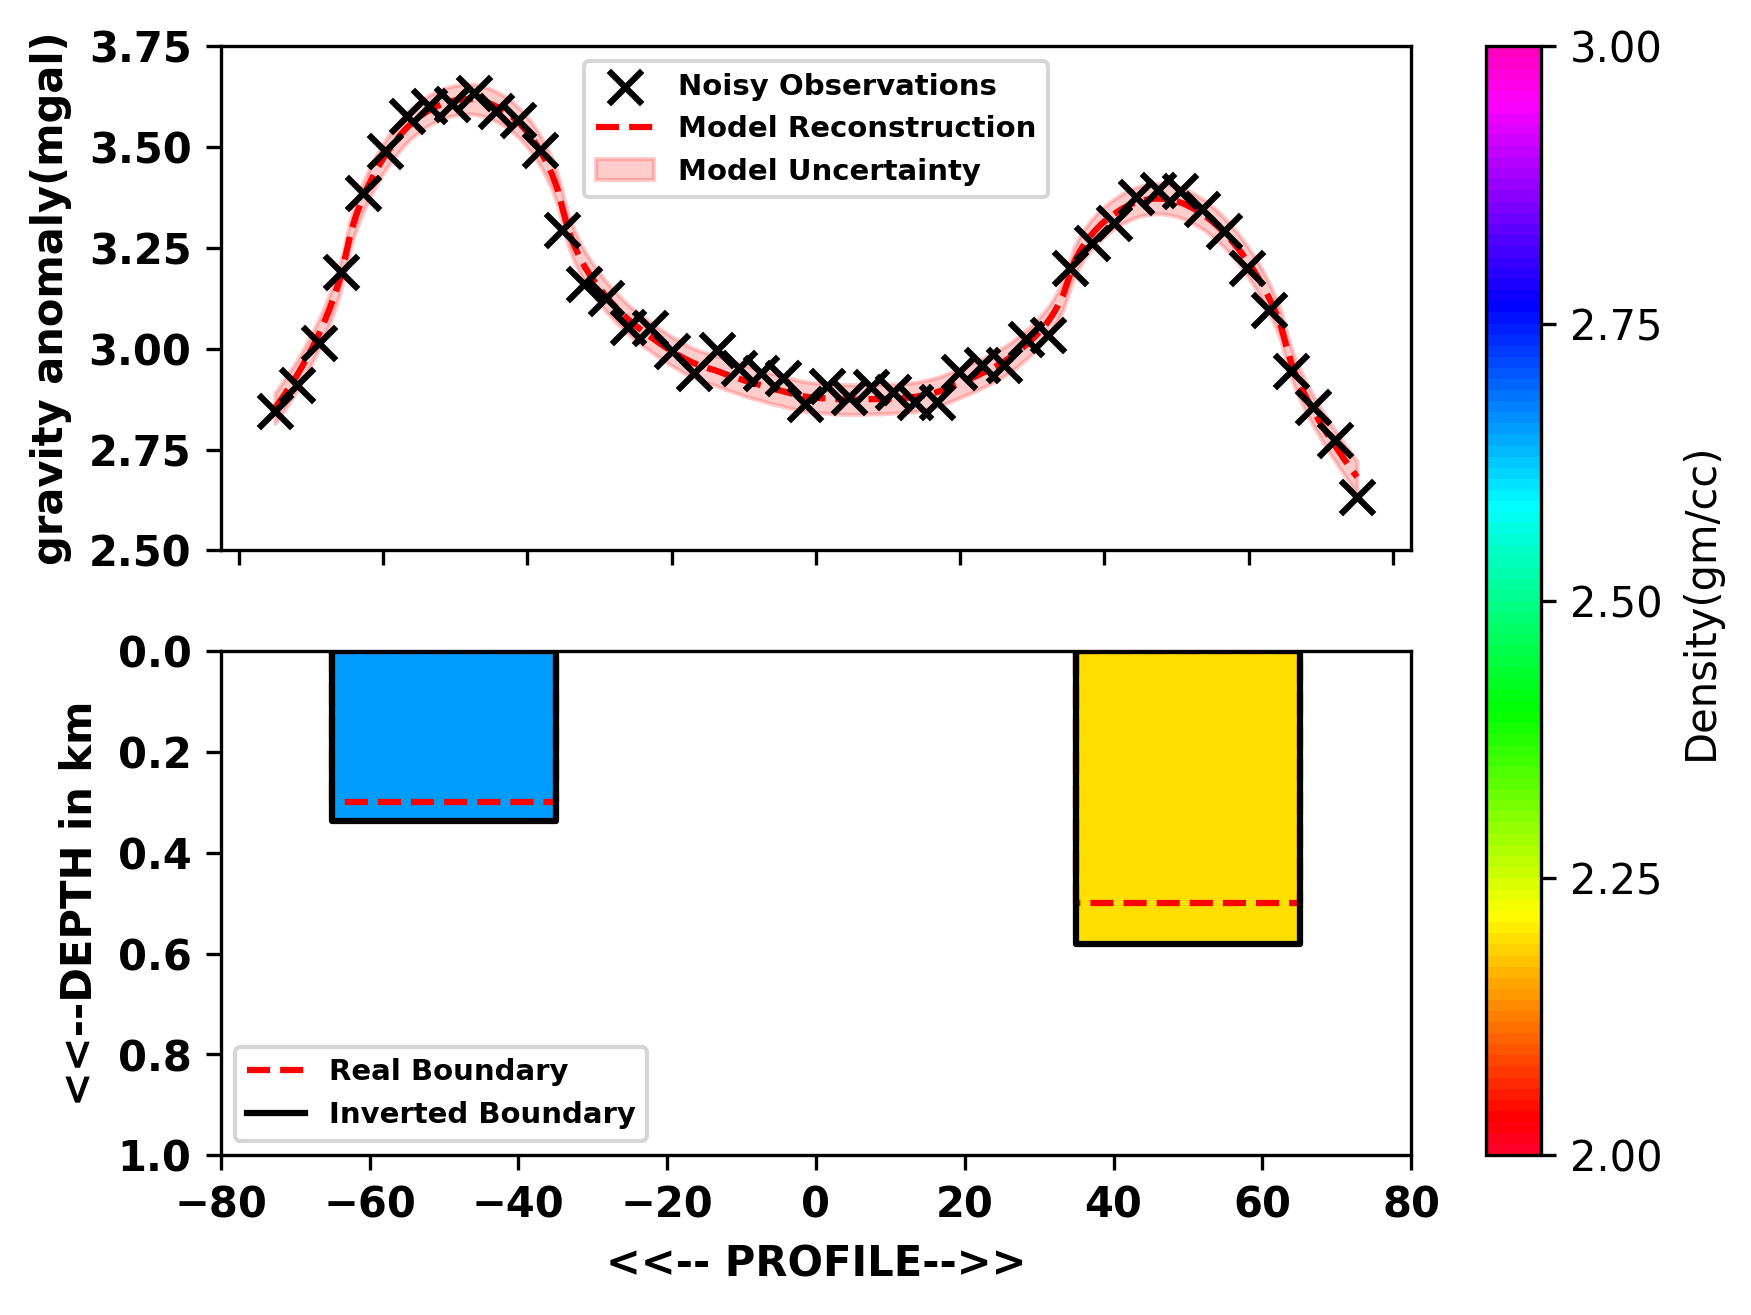

In [ ]:
# Get random number generator keys (see JAX documentation for why it is neccessary)
rng_key, rng_key_predict = gpax.utils.get_keys()
#Using Prior model Bayes_1_Inf and narrow range priors
mean_fn = [Bayes_1_Inf]
mean_fn_priors = [Bayes_1_Inf_prior]
N_Samples=2000
for m, mp in zip(mean_fn, mean_fn_priors):

    # Initialize model
    gp_model = gpax.ExactGP(1, kernel= custom_Matern_kernel_3,kernel_prior=custom_kernel_prior,mean_fn=m,mean_fn_prior=mp)

    # Run MCMC to obtain posterior samples
    gp_model.fit(rng_key, X, y, num_warmup=2000, num_samples=N_Samples)

    # Get GP prediction
    y_pred, y_sampled = gp_model.predict(rng_key_predict, X_test, n=200)

    # Plot results
    fig, axs = plt.subplots(2)
    fig.dpi=300
    axs[0].set_ylabel("gravity anomaly(mgal)",fontsize=10,weight='bold')
    axs[0].scatter(X, y, marker='x', s=64,c='k', label="Noisy Observations", zorder=1)
    axs[0].plot(X_test, y_pred, '--', c='red', label='Model Reconstruction', zorder=0) #model reconstructions

    axs[0].fill_between(X_test, y_pred - y_sampled.std((0,1)), y_pred + y_sampled.std((0,1)),
                            color='r', alpha=0.2, label="Model Uncertainty", zorder=0) #model uncertainty
    axs[0].legend()
    axs[0].set_ylim(2.5,3.75)
    #getting inverted parameters
    params2 = gp_model.get_samples()
    params2.keys()
    cmap_V= plt.get_cmap('gist_rainbow',100)
    maximum_V=3#maximum density value in color scale in gm/cc
    minimum_V=2#minimum density value in color scale in gm/cc
    diff_V=(maximum_V - minimum_V)
    color_index_V = np.linspace(minimum_V,maximum_V,1)
    #choosing the color depending upon the inverted density value of 1st prism
    index_value_V1 = (params2["density_1"].mean()-minimum_V)/diff_V
    color_V1 = cmap_V(index_value_V1)
    #choosing the color depending upon the inverted density value of 2nd prism
    index_value_V2 = (params2["density_2"].mean()-minimum_V)/diff_V
    color_V2 = cmap_V(index_value_V2)
    norm = mpl.colors.Normalize(vmin=minimum_V, vmax=maximum_V)
    sm = plt.cm.ScalarMappable(cmap=cmap_V, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ticks=np.linspace(minimum_V,maximum_V,5),ax=axs.ravel().tolist(),label='Density(gm/cc)')#plotting colorscale
    #creating a prism using 4 corner co-ordinates using inverted results
    coord1 = [[-65,0], [-35,0], [-35,params2['B_D1'].mean()], [-65,params2['B_D1'].mean()]]
    coord2 = [[35,0], [65,0], [65,params2['B_D2'].mean()], [35, params2['B_D2'].mean()]]
    coord1.append(coord1[0]) #repeat the first point to create a 'closed loop'
    coord2.append(coord2[0]) #repeat the first point to create a 'closed loop'
    xs1, ys1 = zip(*coord1) #create lists of x and y values
    xs2, ys2 = zip(*coord2) #create lists of x and y values
    #creating a prism using 4 corner co-ordinates using real values
    coord3 = [[-65,0], [-35,0], [-35,0.3], [-65,0.3]]
    coord4 = [[35,0], [65,0], [65,0.5], [35,0.5]]
    coord3.append(coord3[0]) #repeat the first point to create a 'closed loop'
    coord4.append(coord4[0]) #repeat the first point to create a 'closed loop'
    xs3, ys3 = zip(*coord3) #create lists of x and y values
    xs4, ys4 = zip(*coord4) #create lists of x and y values
    axs[1].plot(xs3,ys3,'red',linestyle='dashed')#plotting prism1 using real values
    axs[1].plot(xs1,ys1,'k')#plotting prism1 using inverted values
    axs[1].fill(xs1, ys1, facecolor=color_V1)#color filling inverted prism1 with inverted density value of prism 1
    axs[1].plot(xs4,ys4,'red',linestyle='dashed')#plotting prism2 using real values
    axs[1].plot(xs2,ys2,'k')#plotting prism2 using inverted values
    axs[1].fill(xs2, ys2, facecolor=color_V2)#color filling inverted prism1 with inverted density value of prism 2
    axs[1].set_xlim(-80,80)
    axs[1].set_ylim(1,0)
    legend_properties = {'weight':'bold','size':'7'}
    axs[1].legend(['Real Boundary','Inverted Boundary'],prop=legend_properties)
    axs[0].legend(prop=legend_properties)
    axs[1].set_xlabel('<<-- PROFILE-->>',fontsize=10,weight='bold')
    axs[1].set_ylabel("<<--DEPTH in km",fontsize=10,weight='bold')
    #axs[1].set_xticks(weight='bold')
    plt.setp(axs[1].get_xticklabels(), weight= 'bold')
    plt.setp(axs[1].get_yticklabels(), weight= 'bold')
    plt.setp(axs[0].get_xticklabels(), weight= 'bold',visible=False)
    plt.setp(axs[0].get_yticklabels(), weight= 'bold')
    plt.show()
